In [33]:
# ============================================
# LIBRERÍAS REQUERIDAS
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
import glob
import random
import numpy as np

In [3]:
# ============================================
# 1. CARGAR Y SELECCIONAR MUESTRA DE DATOS
# ============================================
# Establecer seed para reproducibilidad
random.seed(1)

# Buscar archivos CSV de eventos
nov_files = glob.glob("./data/online+retail/split/2019-Nov_part_*.csv")
oct_files = glob.glob("./data/online+retail/split/2019-Oct_part_*.csv")

# Seleccionar 10 archivos aleatorios de cada mes
nov_sample = random.sample(nov_files, 10)
oct_sample = random.sample(oct_files, 10)

print("\n=== DATOS CARGADOS ===\n")
print(f"Archivos seleccionados (Noviembre): {len(nov_sample)}")
print(f"Archivos seleccionados (Octubre): {len(oct_sample)}")


=== DATOS CARGADOS ===

Archivos seleccionados (Noviembre): 10
Archivos seleccionados (Octubre): 10


In [4]:
# ============================================
# 2. CONSOLIDAR DATOS
# ============================================
# Combinar archivos en un único dataframe
files = nov_sample + oct_sample

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(f"Tamaño dataset consolidado: {data.shape[0]:,} registros x {data.shape[1]} columnas")

Tamaño dataset consolidado: 20,000,000 registros x 9 columnas


In [5]:
# ============================================
# 3. PREPARACIÓN Y VARIABLES TEMPORALES
# ============================================
# Convertir timestamp a datetime
data["event_time"] = pd.to_datetime(data["event_time"])

# Crear variables útiles para análisis temporal
data["hour"] = data["event_time"].dt.hour  # hora del evento
data["date"] = data["event_time"].dt.date  # fecha del evento

In [6]:
# ============================================
# 4. EXPLORACIÓN INICIAL DE LOS DATOS
# ============================================
print("\n=== PRIMERAS FILAS DEL DATASET ===\n")
print(data.head())


=== PRIMERAS FILAS DEL DATASET ===

                 event_time event_type  product_id          category_id  \
0 2019-11-14 08:39:08+00:00       view     1005232  2053013555631882655   
1 2019-11-14 08:39:08+00:00       cart     3600666  2053013563810775923   
2 2019-11-14 08:39:09+00:00       view     1005160  2053013555631882655   
3 2019-11-14 08:39:09+00:00       view     1005239  2053013555631882655   
4 2019-11-14 08:39:09+00:00       view    26500318  2053013563550729061   

               category_code    brand   price    user_id  \
0     electronics.smartphone   xiaomi  118.15  530056071   
1  appliances.kitchen.washer  samsung  321.73  517658709   
2     electronics.smartphone   xiaomi  203.03  556643578   
3     electronics.smartphone   xiaomi  268.96  512886445   
4                        NaN  lucente   25.48  541888295   

                           user_session  hour        date  
0  8a868f47-c065-4600-829d-fcee14fbb365     8  2019-11-14  
1  ec3cc5c8-3572-4f79-ada8-63ac

In [7]:
# Información de estructura y tipos de datos
print("\n=== ESTRUCTURA DEL DATASET ===\n")
print(data.info())


=== ESTRUCTURA DEL DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000000 entries, 0 to 19999999
Data columns (total 11 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[ns, UTC]
 1   event_type     object             
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  object             
 5   brand          object             
 6   price          float64            
 7   user_id        int64              
 8   user_session   object             
 9   hour           int32              
 10  date           object             
dtypes: datetime64[ns, UTC](1), float64(1), int32(1), int64(3), object(5)
memory usage: 1.6+ GB
None


In [8]:
# Análisis de valores nulos
print("\n=== PROPORCIÓN DE VALORES NULOS ===\n")
print(data.isnull().sum() / data.shape[0])


=== PROPORCIÓN DE VALORES NULOS ===

event_time       0.000000e+00
event_type       0.000000e+00
product_id       0.000000e+00
category_id      0.000000e+00
category_code    3.172597e-01
brand            1.445045e-01
price            0.000000e+00
user_id          0.000000e+00
user_session     5.000000e-08
hour             0.000000e+00
date             0.000000e+00
dtype: float64


In [9]:
# Estadísticas descriptivas numéricas
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===\n")
print(data.describe())


=== ESTADÍSTICAS DESCRIPTIVAS ===

         product_id   category_id         price       user_id          hour
count  2.000000e+07  2.000000e+07  2.000000e+07  2.000000e+07  2.000000e+07
mean   1.172955e+07  2.057702e+18  2.931069e+02  5.362526e+08  1.192329e+01
std    1.523765e+07  1.942078e+16  3.567542e+02  2.107486e+07  4.938234e+00
min    1.000978e+06  2.053014e+18  0.000000e+00  4.948454e+07  0.000000e+00
25%    1.005253e+06  2.053014e+18  6.937000e+01  5.162460e+08  8.000000e+00
50%    5.100337e+06  2.053014e+18  1.670600e+02  5.322198e+08  1.300000e+01
75%    1.720082e+07  2.053014e+18  3.603400e+02  5.554910e+08  1.600000e+01
max    1.000285e+08  2.187708e+18  2.574070e+03  5.797422e+08  2.300000e+01


In [10]:
# ============================================
# 5. ANÁLISIS DE TIPOS DE EVENTOS
# ============================================
# Distribución de frecuencias de eventos
event_counts = data["event_type"].value_counts()

print("\n=== DISTRIBUCIÓN DE TIPOS DE EVENTO ===\n")
print(event_counts)
print(f"\n=== PROPORCIÓN (%) ===\n")
print((data["event_type"].value_counts(normalize=True) * 100).round(2))


=== DISTRIBUCIÓN DE TIPOS DE EVENTO ===

event_type
view        19017857
cart          703545
purchase      278598
Name: count, dtype: int64

=== PROPORCIÓN (%) ===

event_type
view        95.09
cart         3.52
purchase     1.39
Name: proportion, dtype: float64


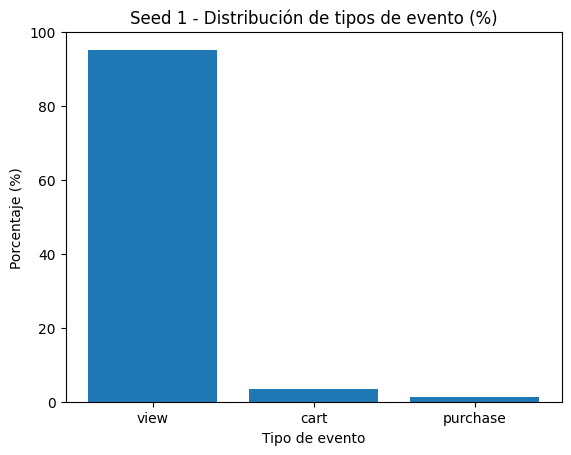

In [11]:
# Visualización: Distribución de tipos de evento
plt.figure()
porcentajes = (event_counts / event_counts.sum() * 100)
plt.bar(porcentajes.index, porcentajes.values)
plt.title("Seed 1 - Distribución de tipos de evento (%)")
plt.xlabel("Tipo de evento")
plt.ylabel("Porcentaje (%)")
plt.ylim(0, 100)
plt.show()

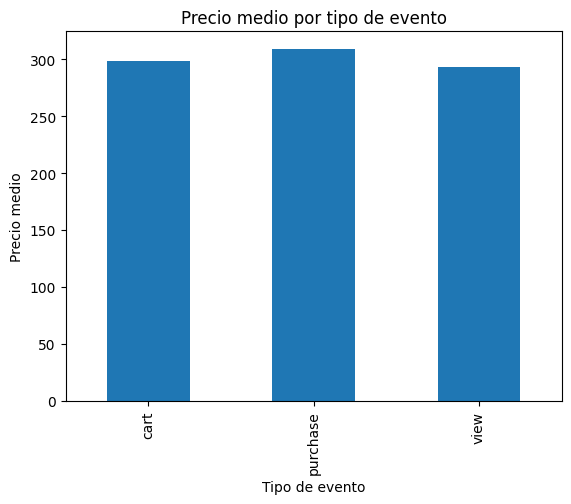

In [ ]:
# Análisis de precios por tipo de evento
price_event = data.groupby("event_type")["price"].mean()

# Visualización: Precio promedio por tipo de evento
plt.figure()
price_event.plot(kind="bar")
plt.title("Precio medio por tipo de evento")
plt.xlabel("Tipo de evento")
plt.ylabel("Precio medio")
plt.show()

In [12]:
# ============================================
# 6. ANÁLISIS DE EVENTOS POR USUARIO
# ============================================
# Contar eventos por usuario
events_user = data.groupby("user_id").size()
distribution = events_user.value_counts().sort_index()

print("\n=== DISTRIBUCIÓN DE EVENTOS POR USUARIO (Primeras 20) ===\n")
print(distribution.head(20))


=== DISTRIBUCIÓN DE EVENTOS POR USUARIO (Primeras 20) ===

1     451167
2     244925
3     177636
4     134691
5     103752
6      84406
7      71042
8      60210
9      51809
10     45468
11     39585
12     35214
13     31080
14     28280
15     25279
16     23008
17     20668
18     19083
19     17414
20     15828
Name: count, dtype: int64


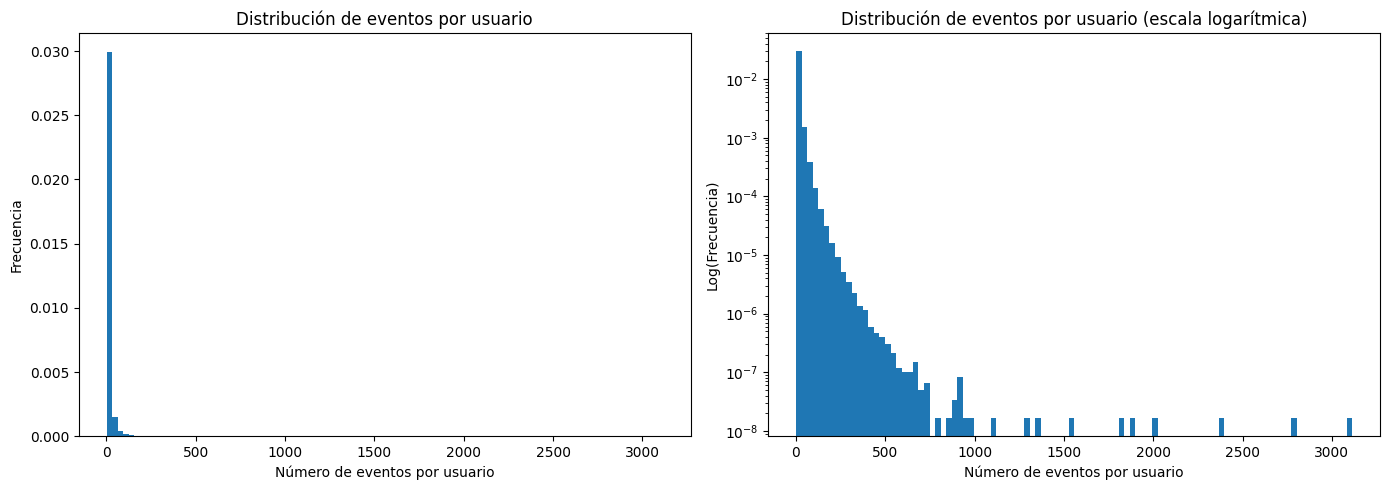

In [ ]:
# Visualización: Histograma de eventos por usuario
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Primer gráfico - escala lineal
ax1.hist(events_user, bins=100, density=True)
ax1.set_title("Seed 1 - Distribución de eventos por usuario")
ax1.set_xlabel("Número de eventos por usuario")
ax1.set_ylabel("Frecuencia")

# Segundo gráfico - escala logarítmica
ax2.hist(events_user, bins=100, density=True, log=True)
ax2.set_title("Seed 1 - Distribución de eventos por usuario (escala logarítmica)")
ax2.set_xlabel("Número de eventos por usuario")
ax2.set_ylabel("Log(Frecuencia)")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 7. ANÁLISIS DE MARCAS
# ============================================
# Top 10 marcas por frecuencia
print("\n=== TOP 10 MARCAS ===\n")
print(data["brand"].value_counts().head(10))


=== TOP 10 MARCAS ===

brand
samsung    2406620
apple      1864265
xiaomi     1394835
huawei      463812
lucente     342806
lg          308471
bosch       280665
oppo        243406
sony        224795
acer        209127
Name: count, dtype: int64


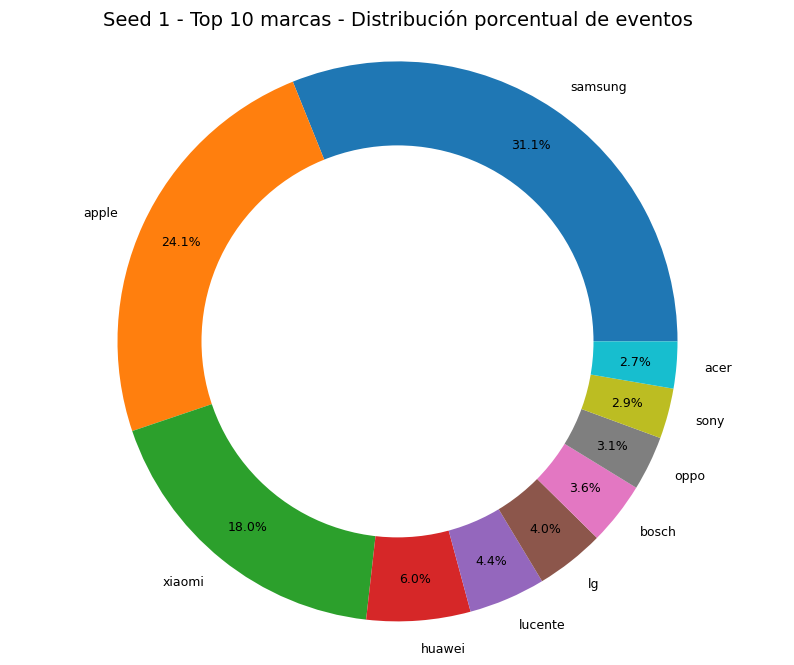

In [28]:
# Visualización: Top 10 marcas - Donut chart
top_brands = data["brand"].value_counts().head(10)

plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    top_brands,
    labels=top_brands.index,
    autopct="%1.1f%%",
    pctdistance=0.85,
    textprops={"fontsize": 9}
)

# Crear el agujero central (donut)
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Seed 1 - Top 10 marcas - Distribución porcentual de eventos", fontsize=14)
plt.axis("equal")
plt.show()

In [30]:
# ============================================
# 8. ANÁLISIS DE CATEGORÍAS
# ============================================
# Top 10 categorías
top_categories = data["category_code"].value_counts().head(10)

print("\n=== TOP 10 CATEGORÍAS ===\n")
print(top_categories)


=== TOP 10 CATEGORÍAS ===

category_code
electronics.smartphone              5073805
electronics.clocks                   628444
electronics.video.tv                 622604
computers.notebook                   607566
electronics.audio.headphone          518270
apparel.shoes                        494297
appliances.kitchen.refrigerators     428307
appliances.environment.vacuum        419427
appliances.kitchen.washer            416831
computers.desktop                    206272
Name: count, dtype: int64


In [31]:
# Análisis de categorías en compras
purchases = data[data["event_type"] == "purchase"]

print("\n=== TOP 10 CATEGORÍAS EN COMPRAS ===\n")
print(purchases["category_code"].value_counts().head(10))


=== TOP 10 CATEGORÍAS EN COMPRAS ===

category_code
electronics.smartphone              124841
electronics.audio.headphone          12436
electronics.video.tv                  8697
electronics.clocks                    7051
appliances.kitchen.washer             5964
computers.notebook                    5837
appliances.environment.vacuum         4911
appliances.kitchen.refrigerators      3938
apparel.shoes                         2352
electronics.tablet                    2122
Name: count, dtype: int64


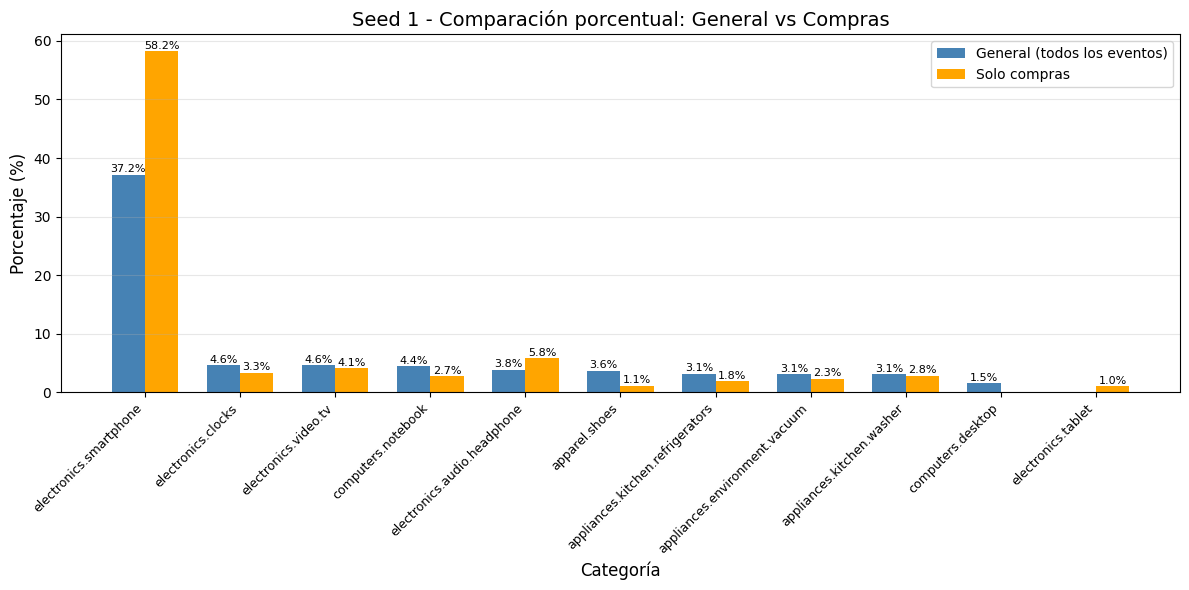

In [43]:

# Obtener los datos
top_categories = data["category_code"].value_counts().head(10)
top_purchase_categories = purchases["category_code"].value_counts().head(10)

# Convertir a porcentajes
total_general = data["category_code"].value_counts().sum()
total_compras = purchases["category_code"].value_counts().sum()

pct_general = (top_categories / total_general) * 100
pct_compras = (top_purchase_categories / total_compras) * 100

# Crear DataFrame de comparación
comparison_pct = pd.DataFrame({
    'General (%)': pct_general,
    'Compras (%)': pct_compras
}).fillna(0)
comparison_pct = comparison_pct.sort_values('General (%)', ascending=False)

# Gráfico de barras agrupadas con porcentajes
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_pct.index))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_pct['General (%)'], width, label='General (todos los eventos)', color='steelblue')
bars2 = ax.bar(x + width/2, comparison_pct['Compras (%)'], width, label='Solo compras', color='orange')

ax.set_xlabel('Categoría', fontsize=12)
ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_title('Seed 1 - Comparación porcentual: General vs Compras', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(comparison_pct.index, rotation=45, ha='right', fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Añadir etiquetas de valor en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

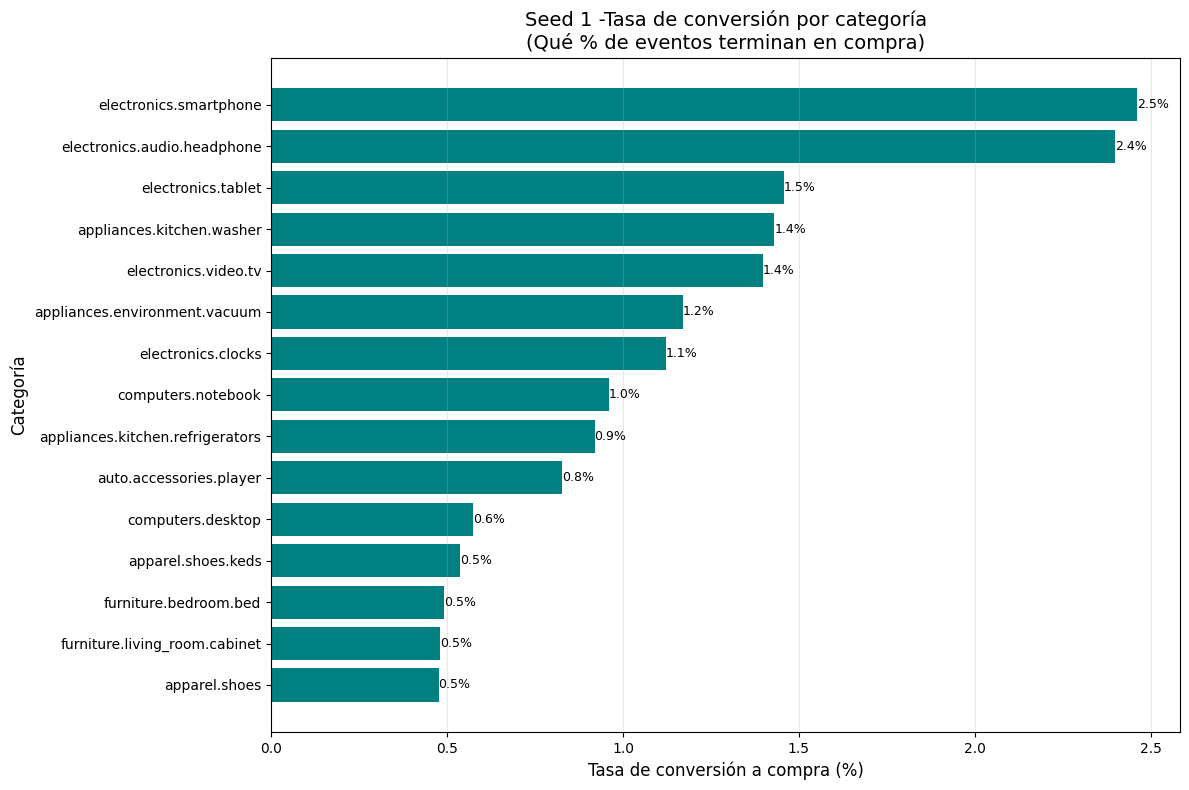


=== CATEGORÍAS CON MAYOR DIFERENCIA ===

                                  General   Compras  Diferencia
category_code                                                  
electronics.smartphone            5073805  124841.0   4948964.0
electronics.clocks                 628444    7051.0    621393.0
electronics.video.tv               622604    8697.0    613907.0
computers.notebook                 607566    5837.0    601729.0
electronics.audio.headphone        518270   12436.0    505834.0
apparel.shoes                      494297    2352.0    491945.0
appliances.kitchen.refrigerators   428307    3938.0    424369.0
appliances.environment.vacuum      419427    4911.0    414516.0
appliances.kitchen.washer          416831    5964.0    410867.0
computers.desktop                  206272    1184.0    205088.0


In [ ]:

# Obtener frecuencias
general_counts = data["category_code"].value_counts()
purchase_counts = purchases["category_code"].value_counts()

# Crear DataFrame con todas las categorías
all_categories = set(general_counts.index) | set(purchase_counts.index)
comparison_full = pd.DataFrame({
    'General': general_counts,
    'Compras': purchase_counts
}).fillna(0)

# Calcular tasa de conversión a compra
comparison_full['Tasa_Conversion'] = (comparison_full['Compras'] / comparison_full['General'] * 100).fillna(0)

# Top 15 por frecuencia general para visualizar
top_15 = comparison_full.nlargest(15, 'General')

# Gráfico de barras horizontales para tasa de conversión
fig, ax = plt.subplots(figsize=(12, 8))

# Ordenar por tasa de conversión
top_15_sorted = top_15.sort_values('Tasa_Conversion', ascending=True)

bars = ax.barh(top_15_sorted.index, top_15_sorted['Tasa_Conversion'], color='teal')
ax.set_xlabel('Tasa de conversión a compra (%)', fontsize=12)
ax.set_ylabel('Categoría', fontsize=12)
ax.set_title('Seed 1 -Tasa de conversión por categoría\n(Qué % de eventos terminan en compra)', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

# Añadir etiquetas
for i, (bar, val) in enumerate(zip(bars, top_15_sorted['Tasa_Conversion'])):
    ax.text(val , bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Mostrar diferencias notables
print("\n=== CATEGORÍAS CON MAYOR DIFERENCIA ===\n")
comparison_full['Diferencia'] = comparison_full['General'] - comparison_full['Compras']
print(comparison_full.nlargest(10, 'Diferencia')[['General', 'Compras', 'Diferencia']])

In [ ]:
# ============================================
# 9. ANÁLISIS DE PRECIOS
# ============================================
print("\n=== ESTADÍSTICAS DE PRECIOS ===\n")
print(f"Precio promedio: {data['price'].mean():.2f}")
print(f"Precio máximo: {data['price'].max():.2f}")
print(f"Precio mínimo: {data['price'].min():.2f}")


=== ESTADÍSTICAS DE PRECIOS ===

Precio promedio: 293.11
Precio máximo: 2574.07
Precio mínimo: 0.00


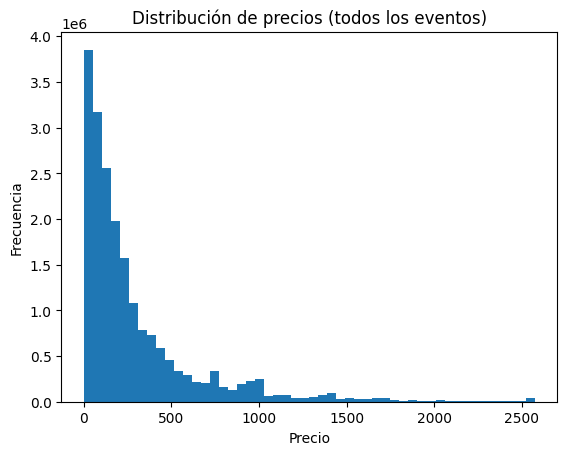

In [ ]:
# Visualización: Distribución de precios
plt.figure()
plt.hist(data["price"].dropna(), bins=50)
plt.title("Distribución de precios (todos los eventos)")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

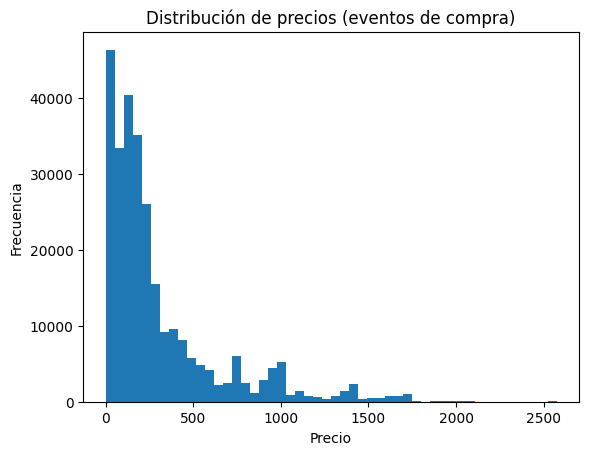

In [ ]:
# Visualización: Distribución de precios en compras
purchase_prices = purchases["price"]

plt.figure()
plt.hist(purchase_prices.dropna(), bins=50)
plt.title("Distribución de precios (eventos de compra)")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# ============================================
# 10. ANÁLISIS DE COBERTURA DE USUARIOS Y SESIONES
# ============================================
print("\n=== COBERTURA DE USUARIOS Y SESIONES ===\n")
print(f"Usuarios únicos: {data['user_id'].nunique():,}")
print(f"Sesiones únicas: {data['user_session'].nunique():,}")


=== COBERTURA DE USUARIOS Y SESIONES ===

Usuarios únicos: 1,932,110
Sesiones únicas: 4,165,281


In [ ]:
# Información adicional de sesiones
print(f"Promedio de eventos por sesión: {len(data) / data['user_session'].nunique():.2f}")

Promedio de eventos por sesión: 4.80


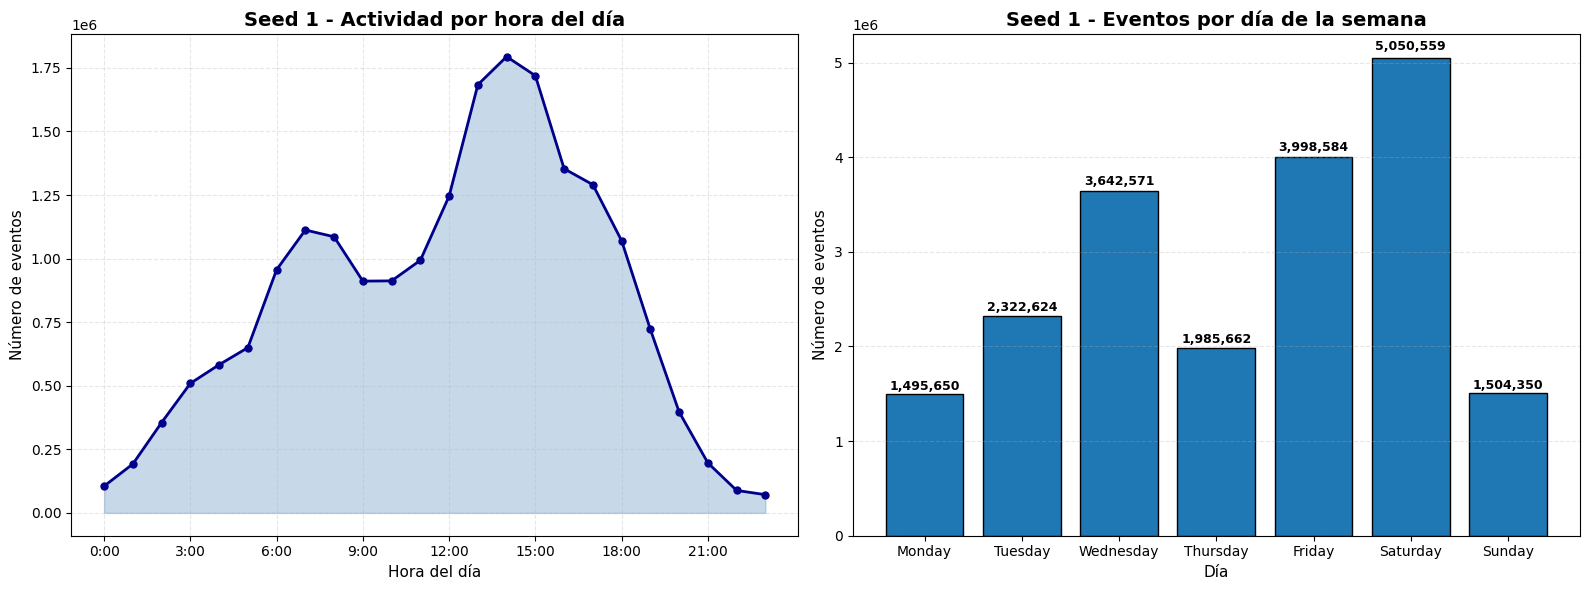


=== ESTADÍSTICAS DE ACTIVIDAD ===

Hora pico: 14 (1,794,171 eventos)
Hora valle: 23 (71,713 eventos)
Día más activo: Saturday (5,050,559 eventos)
Día menos activo: Monday (1,495,650 eventos)


In [48]:
# ============================================
# 11. ANÁLISIS TEMPORAL
# ============================================
# Datos por hora
data["hour"] = data["event_time"].dt.hour
events_hour = data.groupby("hour").size()

# Datos por día de la semana
data["weekday"] = data["event_time"].dt.day_name()
weekday_events = data.groupby("weekday").size()
weekday_events = weekday_events.reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

# ============================================
# GRÁFICOS LADO A LADO - VERSIÓN MEJORADA
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Actividad por hora (área rellena)
ax1.fill_between(events_hour.index, events_hour.values, alpha=0.3, color='steelblue')
ax1.plot(events_hour.index, events_hour.values, marker='o', linewidth=2, markersize=5, color='darkblue')
ax1.set_title("Seed 1 - Actividad por hora del día", fontsize=14, fontweight='bold')
ax1.set_xlabel("Hora del día", fontsize=11)
ax1.set_ylabel("Número de eventos", fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(range(0, 24, 3))  # Mostrar cada 3 horas: 0, 3, 6, ..., 21
ax1.set_xticklabels([f"{h}:00" for h in range(0, 24, 3)])

# Gráfico 2: Eventos por día de la semana
bars = ax2.bar(weekday_events.index, weekday_events.values,  edgecolor='black', linewidth=1)
ax2.set_title("Seed 1 - Eventos por día de la semana", fontsize=14, fontweight='bold')
ax2.set_xlabel("Día", fontsize=11)
ax2.set_ylabel("Número de eventos", fontsize=11)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# Añadir etiquetas de valor en las barras
for bar, value in zip(bars, weekday_events.values):
    ax2.text(bar.get_x() + bar.get_width()/2., value + value*0.01,
             f'{int(value):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# ESTADÍSTICAS ADICIONALES (opcional)
# ============================================
print("\n=== ESTADÍSTICAS DE ACTIVIDAD ===\n")
print(f"Hora pico: {events_hour.idxmax()} ({events_hour.max():,} eventos)")
print(f"Hora valle: {events_hour.idxmin()} ({events_hour.min():,} eventos)")
print(f"Día más activo: {weekday_events.idxmax()} ({weekday_events.max():,} eventos)")
print(f"Día menos activo: {weekday_events.idxmin()} ({weekday_events.min():,} eventos)")